In [ ]:
# pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


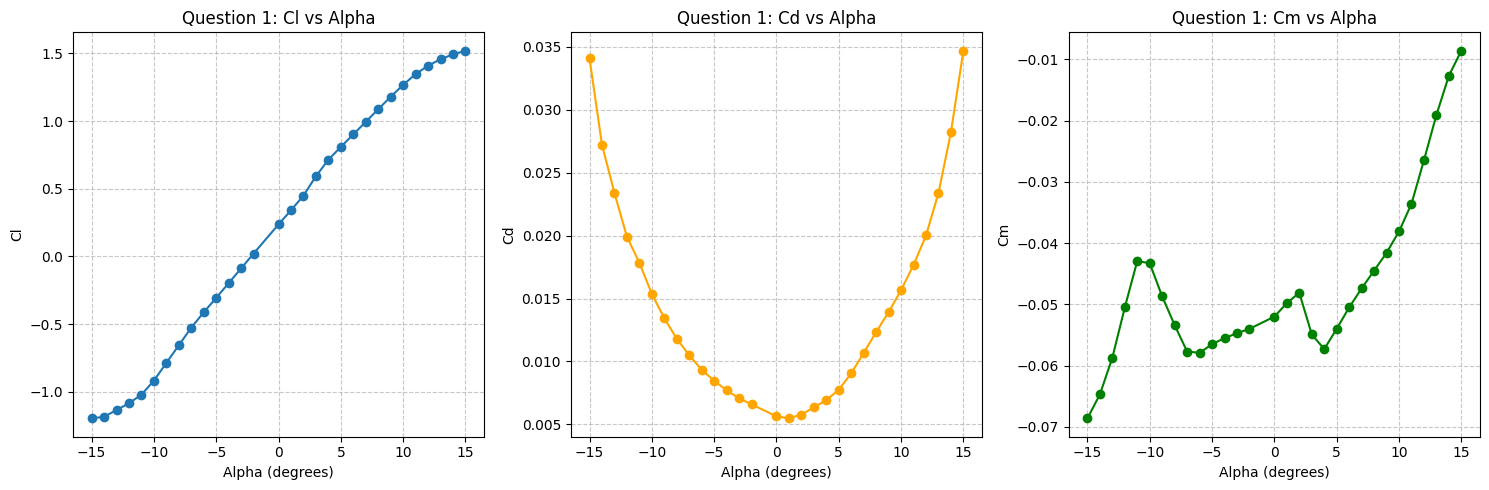

--- Question 3: Cl Base Model (Degree 1) ---
Training MAPE: 11.4645%
Test MAPE:     6.5510%



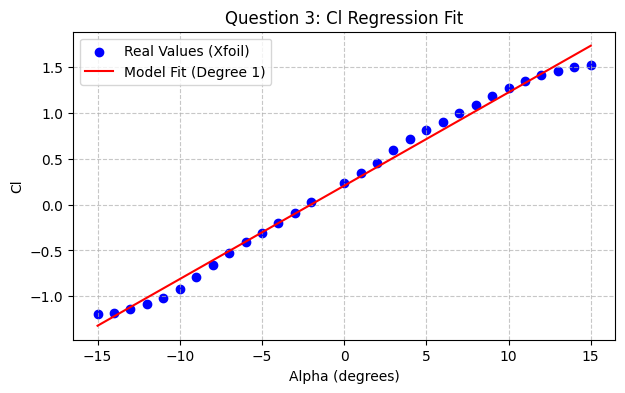

--- Question 3: Cd Base Model (Degree 2) ---
Training MAPE: 7.0312%
Test MAPE:     5.0155%



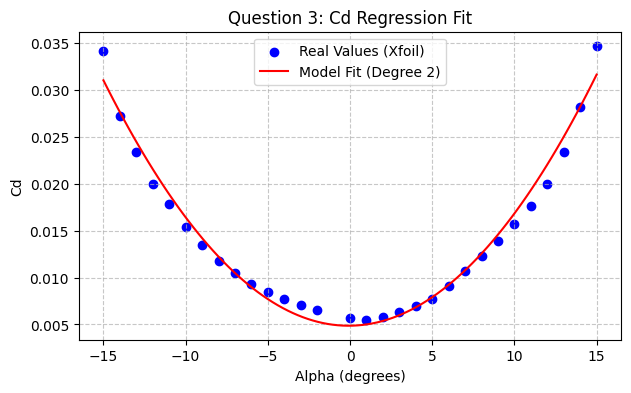

--- Question 3: Cm Base Model (Degree 1) ---
Training MAPE: 29.5596%
Test MAPE:     21.0521%



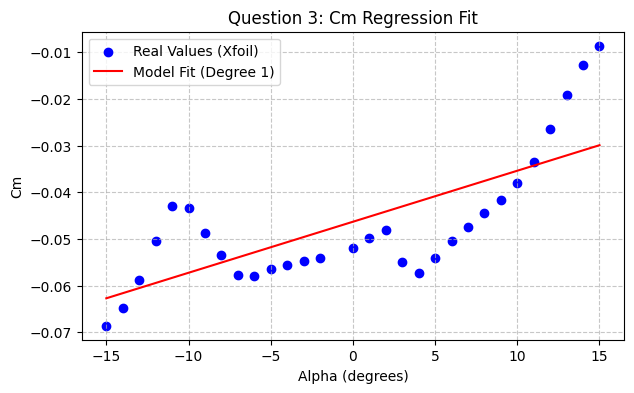

--- Question 3a: Regularization for Cl (Degree 1) ---
Lambda =  0.1 | Test MAPE: 6.5537%
Lambda =  0.5 | Test MAPE: 6.5648%
Lambda =  1.0 | Test MAPE: 6.5787%
Lambda = 10.0 | Test MAPE: 6.8268%

--- Question 3a: Regularization for Cd (Degree 2) ---
Lambda =  0.1 | Test MAPE: 5.0154%
Lambda =  0.5 | Test MAPE: 5.0150%
Lambda =  1.0 | Test MAPE: 5.0145%
Lambda = 10.0 | Test MAPE: 5.0057%

--- Question 3a: Regularization for Cm (Degree 1) ---
Lambda =  0.1 | Test MAPE: 21.0526%
Lambda =  0.5 | Test MAPE: 21.0546%
Lambda =  1.0 | Test MAPE: 21.0572%
Lambda = 10.0 | Test MAPE: 21.1026%

--- Question 3b: Models Trained on Denser Dataset (0.5 steps) ---
--- Question 3: Cl (Dense) Base Model (Degree 1) ---
Training MAPE: 9.1547%
Test MAPE:     9.6949%



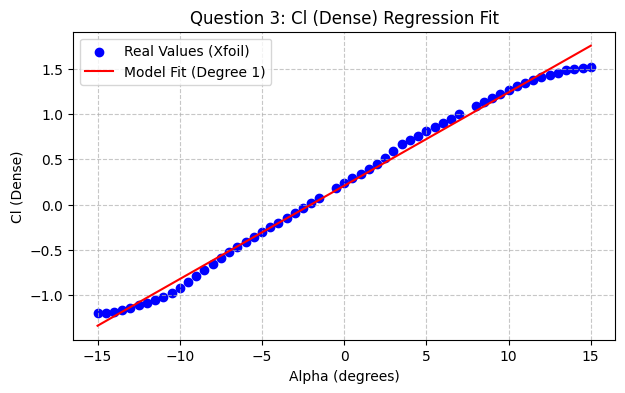

--- Question 3: Cd (Dense) Base Model (Degree 2) ---
Training MAPE: 4.7251%
Test MAPE:     5.2385%



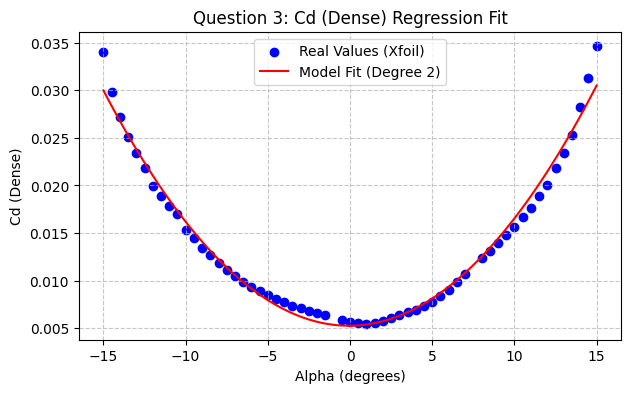

--- Question 3: Cm (Dense) Base Model (Degree 1) ---
Training MAPE: 25.5577%
Test MAPE:     29.3929%



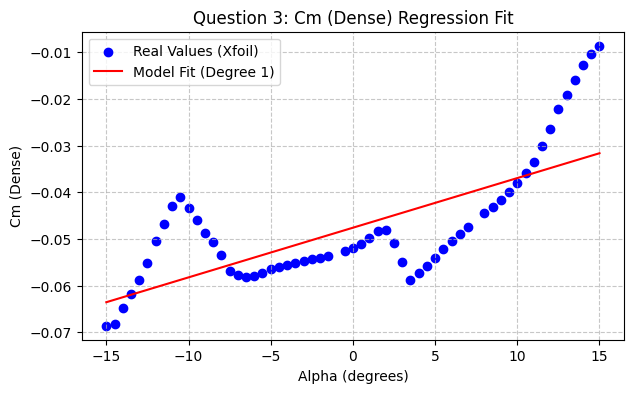

--- Q4 Final Evaluation for Cl ---
Evaluation MAPE: 17.6092%



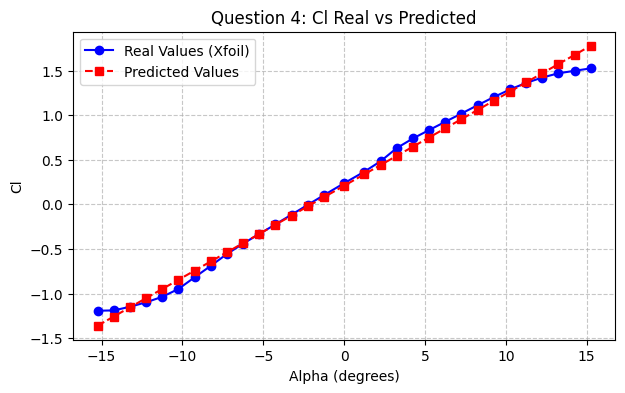

--- Q4 Final Evaluation for Cd ---
Evaluation MAPE: 5.4009%



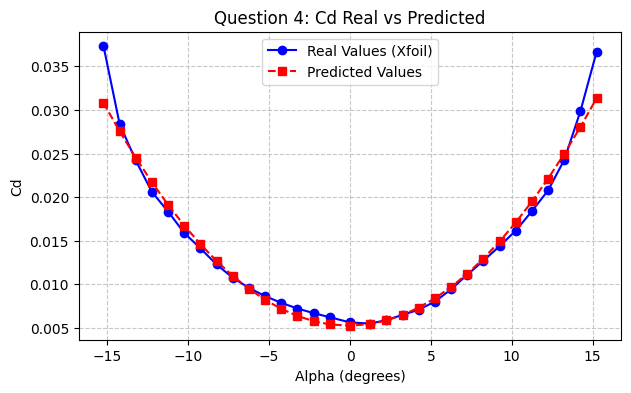

--- Q4 Final Evaluation for Cm ---
Evaluation MAPE: 30.4336%



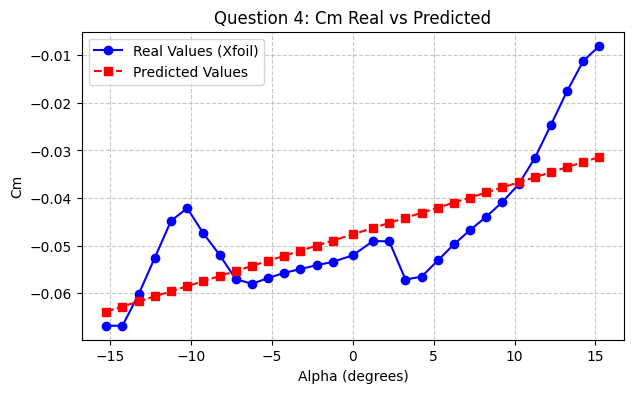

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def calculate_mape(y_true, y_pred):
    """Calculates the exact MAPE as defined in the assignment."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def load_xfoil_data(filepath, skip_rows=12):
    """Loads Xfoil polar data, skips headers, and sorts by alpha."""
    cols = ['alpha', 'CL', 'CD', 'CDp', 'CM', 'Top_Xtr', 'Bot_Xtr', 'Top_Itr', 'Bot_Itr']
    df = pd.read_csv(filepath, sep='\s+', skiprows=skip_rows, names=cols)
    df = df.sort_values(by='alpha').reset_index(drop=True)
    return df

df_base = load_xfoil_data('naca2412.txt')

X = df_base[['alpha']]
y_cl = df_base['CL']
y_cd = df_base['CD']
y_cm = df_base['CM']

# 80/20 Train-Test Split
X_train, X_test, y_cl_train, y_cl_test = train_test_split(X, y_cl, test_size=0.20, random_state=42)
_, _, y_cd_train, y_cd_test = train_test_split(X, y_cd, test_size=0.20, random_state=42)
_, _, y_cm_train, y_cm_test = train_test_split(X, y_cm, test_size=0.20, random_state=42)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].plot(df_base['alpha'], df_base['CL'], marker='o', linestyle='-')
axs[0].set_title('Question 1: Cl vs Alpha')
axs[0].set_xlabel('Alpha (degrees)')
axs[0].set_ylabel('Cl')
axs[0].grid(True, linestyle='--', alpha=0.7)

axs[1].plot(df_base['alpha'], df_base['CD'], marker='o', linestyle='-', color='orange')
axs[1].set_title('Question 1: Cd vs Alpha')
axs[1].set_xlabel('Alpha (degrees)')
axs[1].set_ylabel('Cd')
axs[1].grid(True, linestyle='--', alpha=0.7)

axs[2].plot(df_base['alpha'], df_base['CM'], marker='o', linestyle='-', color='green')
axs[2].set_title('Question 1: Cm vs Alpha')
axs[2].set_xlabel('Alpha (degrees)')
axs[2].set_ylabel('Cm')
axs[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show() 

degree_cl = 1
degree_cd = 2
degree_cm = 1

def build_and_evaluate_model(X_tr, y_tr, X_te, y_te, X_full, y_full, degree, param_name):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_tr, y_tr)
    mape_train = calculate_mape(y_tr, model.predict(X_tr))
    mape_test = calculate_mape(y_te, model.predict(X_te))
    print(f"--- Question 3: {param_name} Base Model (Degree {degree}) ---")
    print(f"Training MAPE: {mape_train:.4f}%")
    print(f"Test MAPE:     {mape_test:.4f}%\n")
    plt.figure(figsize=(7, 4))
    plt.scatter(X_full['alpha'], y_full, label='Real Values (Xfoil)', color='blue')
    x_range = np.linspace(X_full['alpha'].min(), X_full['alpha'].max(), 100)
    x_smooth = pd.DataFrame({'alpha': x_range})
    y_smooth = model.predict(x_smooth)
    plt.plot(x_smooth['alpha'], y_smooth, color='red', label=f'Model Fit (Degree {degree})')
    plt.title(f'Question 3: {param_name} Regression Fit')
    plt.xlabel('Alpha (degrees)')
    plt.ylabel(param_name)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    return model

model_cl = build_and_evaluate_model(X_train, y_cl_train, X_test, y_cl_test, X, y_cl, degree_cl, "Cl")
model_cd = build_and_evaluate_model(X_train, y_cd_train, X_test, y_cd_test, X, y_cd, degree_cd, "Cd")
model_cm = build_and_evaluate_model(X_train, y_cm_train, X_test, y_cm_test, X, y_cm, degree_cm, "Cm")
lambdas = [0.1, 0.5, 1.0, 10.0]

def evaluate_regularization(X_tr, y_tr, X_te, y_te, degree, param_name):
    print(f"--- Question 3a: Regularization for {param_name} (Degree {degree}) ---")
    for lam in lambdas:
        model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=lam))
        model.fit(X_tr, y_tr)
        mape_test = calculate_mape(y_te, model.predict(X_te))
        print(f"Lambda = {lam:4.1f} | Test MAPE: {mape_test:.4f}%")
    print()

evaluate_regularization(X_train, y_cl_train, X_test, y_cl_test, degree_cl, "Cl")
evaluate_regularization(X_train, y_cd_train, X_test, y_cd_test, degree_cd, "Cd")
evaluate_regularization(X_train, y_cm_train, X_test, y_cm_test, degree_cm, "Cm")
df_dense = load_xfoil_data('naca2412_dense.txt')
X_dense = df_dense[['alpha']]
y_cl_dense = df_dense['CL']
y_cd_dense = df_dense['CD']
y_cm_dense = df_dense['CM']
X_tr_d, X_te_d, y_cl_tr_d, y_cl_te_d = train_test_split(X_dense, y_cl_dense, test_size=0.20, random_state=42)
_, _, y_cd_tr_d, y_cd_te_d = train_test_split(X_dense, y_cd_dense, test_size=0.20, random_state=42)
_, _, y_cm_tr_d, y_cm_te_d = train_test_split(X_dense, y_cm_dense, test_size=0.20, random_state=42)

print("--- Question 3b: Models Trained on Denser Dataset (0.5 steps) ---")
model_cl_dense = build_and_evaluate_model(X_tr_d, y_cl_tr_d, X_te_d, y_cl_te_d, X_dense, y_cl_dense, degree_cl, "Cl (Dense)")
model_cd_dense = build_and_evaluate_model(X_tr_d, y_cd_tr_d, X_te_d, y_cd_te_d, X_dense, y_cd_dense, degree_cd, "Cd (Dense)")
model_cm_dense = build_and_evaluate_model(X_tr_d, y_cm_tr_d, X_te_d, y_cm_te_d, X_dense, y_cm_dense, degree_cm, "Cm (Dense)")
df_eval = load_xfoil_data('naca2412_eval.txt')
X_eval = df_eval[['alpha']]
y_cl_eval = df_eval['CL']
y_cd_eval = df_eval['CD']
y_cm_eval = df_eval['CM']

def evaluate_and_plot_q4(X_test_eval, y_true_eval, model, param_name):
    y_pred_eval = model.predict(X_test_eval)
    mape_eval = calculate_mape(y_true_eval, y_pred_eval)
    print(f"--- Q4 Final Evaluation for {param_name} ---")
    print(f"Evaluation MAPE: {mape_eval:.4f}%\n")
    plt.figure(figsize=(7, 4))
    plt.plot(X_test_eval, y_true_eval, 'o-', label='Real Values (Xfoil)', color='blue')
    plt.plot(X_test_eval, y_pred_eval, 's--', label='Predicted Values', color='red')
    plt.title(f'Question 4: {param_name} Real vs Predicted')
    plt.xlabel('Alpha (degrees)')
    plt.ylabel(param_name)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

evaluate_and_plot_q4(X_eval, y_cl_eval, model_cl_dense, "Cl")
evaluate_and_plot_q4(X_eval, y_cd_eval, model_cd_dense, "Cd")
evaluate_and_plot_q4(X_eval, y_cm_eval, model_cm_dense, "Cm")

## Question 2
The parameter for the $c_l$ graph is 1, the parameter for the $c_d$ graph is 2, and the parameter for the $c_m$ graph is 1. This means that the $c_l$ and $c_m$ graph are first order, and the $c_d$ graph is second order.

## Question 3
### a)
$c_l$ outcome:
| Model | $\lambda$ Value | Test MAPE | Improvement? |
| :--- | :--- | :--- | :--- |
| **Base Model** | N/A | 6.5510% | N/A |
| **Regularized** | 0.1 | 6.5537% | No Improvement |
| **Regularized** | 0.5 | 6.5648% | No Improvement |
| **Regularized** | 1.0 | 6.5787% | No Improvement |
| **Regularized** | 10.0 | 6.8268% | No Improvement |

$c_d$ outcome:
| Model | $\lambda$ Value | Test MAPE | Improvement? |
| :--- | :--- | :--- | :--- |
| **Base Model** | N/A | 5.0155% | N/A |
| **Regularized** | 0.1 | 5.0154% | Improved |
| **Regularized** | 0.5 | 5.0150% | Improved |
| **Regularized** | 1.0 | 5.0145% | Improved |
| **Regularized** | 10.0 | 5.0057% | Improved |

$c_m$ outcome:
| Model | $\lambda$ Value | Test MAPE | Improvement? |
| :--- | :--- | :--- | :--- |
| **Base Model** | N/A | 21.0521% | N/A |
| **Regularized** | 0.1 | 21.0526% | No Improvement |
| **Regularized** | 0.5 | 21.0546% | No Improvement |
| **Regularized** | 1.0 | 21.0572% | No Improvement |
| **Regularized** | 10.0 | 21.1026% | No Improvement |

Regularization did not show a significant improvement in the MAPE values. The purpose of regularization is to smooth out complex curves to fit trends, but the linear nature of the model being tested made regularization flatter and further from the true values of the data.

### b)
$c_l$ outcome:
| Model | Dataset Step Size | Test MAPE | Improvement? |
| :--- | :--- | :--- | :--- |
| **Base Model** | 1.0 degree | 6.5510% | N/A |
| **Dense Model** | 0.5 degree | 9.6949% | No Improvement |

$c_d$ outcome:
| Model | Dataset Step Size | Test MAPE | Improvement? |
| :--- | :--- | :--- | :--- |
| **Base Model** | 1.0 degree | 5.0155% | N/A |
| **Dense Model** | 0.5 degree | 5.2385% | No Improvement |

$c_m$ outcome:
| Model | Dataset Step Size | Test MAPE | Improvement? |
| :--- | :--- | :--- | :--- |
| **Base Model** | 1.0 degree | 21.0521% | N/A |
| **Dense Model** | 0.5 degree | 29.3929% | No Improvement |

The increase in the density of the data resulted in a greater MAPE values. The addition of the new points resulted in the overall trend of the data to become curbed which does not match the initial models causing them to try to bend and fit the new trends, increasing the error.

## Question 4
The MAPE for the $c_l$ graph is 17.6092\%, the MAPE for the $c_d$ graph is 5.4009\%, and the MAPE for the $c_m$ graph is 30.4336\%. These values showed how the models learned the underlying trends in the data and not tried to overfit the original data.